In [1]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Country-data.csv to Country-data.csv
{'Country-data.csv': b'country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp\r\nAfghanistan,90.2,10,7.58,44.9,1610,9.44,56.2,5.82,553\r\nAlbania,16.6,28,6.55,48.6,9930,4.49,76.3,1.65,4090\r\nAlgeria,27.3,38.4,4.17,31.4,12900,16.1,76.5,2.89,4460\r\nAngola,119,62.3,2.85,42.9,5900,22.4,60.1,6.16,3530\r\nAntigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200\r\nArgentina,14.5,18.9,8.1,16,18700,20.9,75.8,2.37,10300\r\nArmenia,18.1,20.8,4.4,45.3,6700,7.77,73.3,1.69,3220\r\nAustralia,4.8,19.8,8.73,20.9,41400,1.16,82,1.93,51900\r\nAustria,4.3,51.3,11,47.8,43200,0.873,80.5,1.44,46900\r\nAzerbaijan,39.2,54.3,5.88,20.7,16000,13.8,69.1,1.92,5840\r\nBahamas,13.8,35,7.89,43.7,22900,-0.393,73.8,1.86,28000\r\nBahrain,8.6,69.5,4.97,50.9,41100,7.44,76,2.16,20700\r\nBangladesh,49.4,16,3.52,21.8,2440,7.14,70.4,2.33,758\r\nBarbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000\r\nBelarus,5.5,51.4,5.61,64.5,16200,15.1,7

# Principal Component Analysis (PCA) on Country Development Dataset

## Objective

The objective of this notebook is to understand and implement Principal Component Analysis (PCA) for dimensionality reduction.

PCA helps reduce the number of features while preserving the maximum possible information (variance) present in the dataset.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
countries = df["country"]

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
print("Number of Features Before PCA:", X.shape[1])

Number of Features Before PCA: 9


## Feature Scaling

PCA is sensitive to feature magnitudes. Therefore, all numerical features are standardized before applying PCA.

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Applying PCA

The dataset contains 9 features.

PCA will reduce them to 2 principal components while retaining most of the information present in the original data.

In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [10]:
print("Original Shape :", X_scaled.shape)
print("Reduced Shape  :", X_pca.shape)

Original Shape : (167, 9)
Reduced Shape  : (167, 2)


In [11]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1",
             "Principal Component 2"]
)

pca_df.head()

,Principal Component 1,Principal Component 2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


In [12]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.4595174  0.17181626]


In [13]:
print(
    "Total Variance Preserved:",
    pca.explained_variance_ratio_.sum()
)

Total Variance Preserved: 0.6313336543771411


## PCA Scatter Plot

Each point represents a country.

Countries that appear close together have similar socioeconomic characteristics.

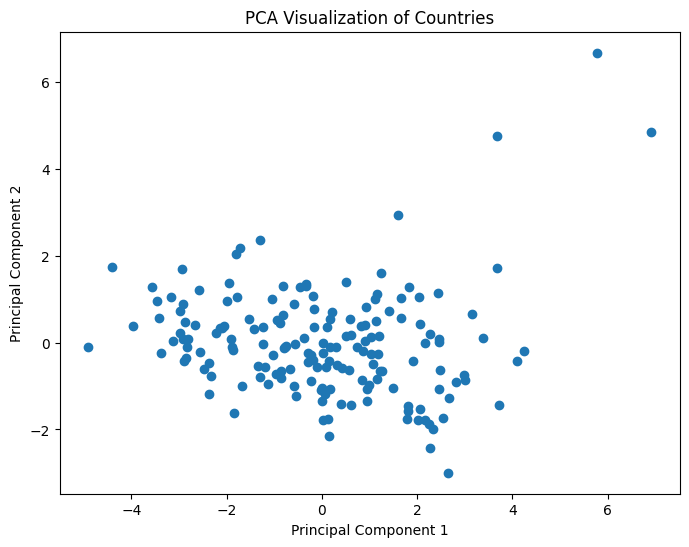

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Visualization of Countries")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [15]:
pca_df["Country"] = countries

pca_df.head()

,Principal Component 1,Principal Component 2,Country
0,-2.913025,0.095621,Afghanistan
1,0.429911,-0.588156,Albania
2,-0.285225,-0.455174,Algeria
3,-2.932423,1.695555,Angola
4,1.033576,0.136659,Antigua and Barbuda


In [16]:
pca_df.head(10)

,Principal Component 1,Principal Component 2,Country
0,-2.913025,0.095621,Afghanistan
1,0.429911,-0.588156,Albania
2,-0.285225,-0.455174,Algeria
3,-2.932423,1.695555,Angola
4,1.033576,0.136659,Antigua and Barbuda
5,0.022407,-1.779187,Argentina
6,-0.101584,-0.568252,Armenia
7,2.342165,-1.988459,Australia
8,2.973764,-0.734689,Austria
9,-0.181487,-0.402866,Azerbaijan


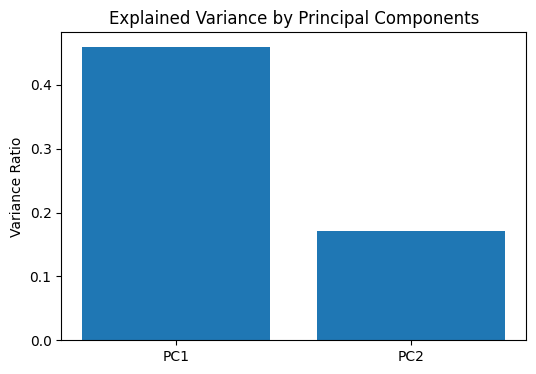

In [17]:
variance = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))

plt.bar(
    ["PC1","PC2"],
    variance
)

plt.title("Explained Variance by Principal Components")

plt.ylabel("Variance Ratio")

plt.show()

## Interpretation

Principal Component 1 captures the largest amount of variation present in the dataset.

Principal Component 2 captures the second largest amount of variation.

Together, these components represent most of the important information while reducing the original feature space from 9 dimensions to 2 dimensions.

This makes visualization and analysis easier while minimizing information loss.

# Conclusion

Principal Component Analysis (PCA) was successfully applied to the Country Development Dataset.

The original dataset contained 9 numerical features. PCA reduced the dimensionality to 2 principal components while preserving a significant portion of the dataset's variance.

The reduced dataset can be visualized using a scatter plot, making it easier to understand patterns and relationships between countries.

PCA is an effective dimensionality reduction technique that simplifies complex datasets while retaining most of the important information.